# Taller 03: Problemas de Satisfacción de Restricciones 

### Grupo: Natalia Carpintero, Paula Núñez e Isabella Arrieta.

**Objetivo:** Diseñe e implemente un algoritmo BT-FC-DO para la solución de Problemas de Satisfacción de Restricciones aplicado a coloreado de grafos. El grafo debe estar definido por una matriz de adyacencias (1: conectado, 0:no conectado) simétrica de tamaño NxN (N < 21). 

Matriz cargada desde archivo: grafo.txt
Número mínimo de colores usados: 2
Asignación por nodo: {1: 0, 2: 1, 3: 0, 4: 1, 0: 1, 5: 0}


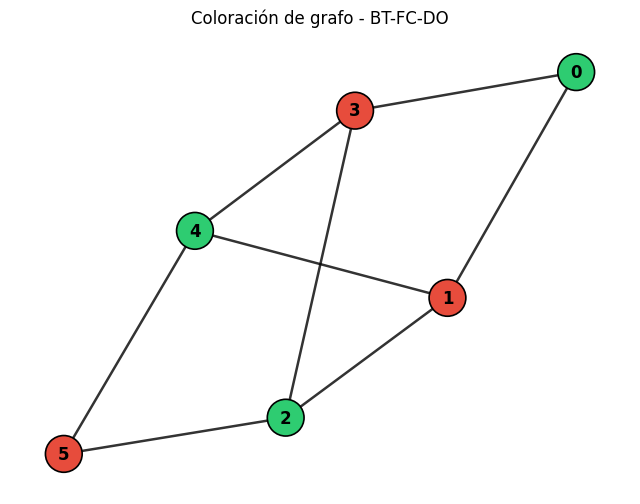

In [4]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------
# Carga de la matriz
# ---------------------------
def leer_matriz_desde_archivo(ruta):
    with open(ruta, 'r', encoding='utf-8') as archivo:
        lineas = []
        for linea in archivo:
            linea = linea.strip()
            if not linea or linea.startswith('#'):
                continue
            fila = [int(x) for x in re.split(r'[\s,;]+', linea) if x]
            lineas.append(fila)
    if not lineas:
        raise ValueError('El archivo no contiene una matriz de adyacencias válida.')
    matriz = np.array(lineas, dtype=int)
    if matriz.shape[0] != matriz.shape[1]:
        raise ValueError('La matriz debe ser cuadrada.')
    if not np.all((matriz == 0) | (matriz == 1)):
        raise ValueError('La matriz solo puede contener 0 o 1.')
    if not np.allclose(matriz, matriz.T):
        raise ValueError('La matriz debe ser simétrica.')
    return matriz

# ---------------------------
# Generación aleatoria
# ---------------------------
def generar_grafo_aleatorio(n, probabilidad=0.35, semilla=42):
    rng = np.random.default_rng(semilla)
    matriz = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < probabilidad:
                matriz[i, j] = 1
                matriz[j, i] = 1
    return matriz

# ---------------------------
# Algoritmo BT-FC-DO
# ---------------------------
def bt_fc_do_coloreo(matriz, num_colores=None):
    n = matriz.shape[0]
    if num_colores is None:
        for k in range(1, n + 1):
            solucion = bt_fc_do_coloreo(matriz, k)
            if solucion is not None:
                return solucion, k
        return None, None

    orden = sorted(range(n), key=lambda v: (-matriz[v].sum(), v))
    dominios = {v: list(range(num_colores)) for v in range(n)}

    def es_compatible(asignacion, vertice, color):
        for otro, valor in asignacion.items():
            if matriz[vertice, otro] == 1 and valor == color:
                return False
        return True

    def propagar(asignacion, dominios_actuales):
        dominios_nuevos = {k: list(v) for k, v in dominios_actuales.items()}
        cambio = True
        while cambio:
            cambio = False
            for v in range(n):
                if v in asignacion:
                    continue
                for u, color in asignacion.items():
                    if matriz[v, u] == 1 and color in dominios_nuevos[v]:
                        dominios_nuevos[v].remove(color)
                        cambio = True
                if not dominios_nuevos[v]:
                    return None
        return dominios_nuevos

    def resolver(asignacion, dominios_actuales):
        if len(asignacion) == n:
            return asignacion.copy()
        no_asignados = [v for v in orden if v not in asignacion]
        v = min(no_asignados, key=lambda x: (len(dominios_actuales[x]), -matriz[x].sum()))
        for color in dominios_actuales[v]:
            if not es_compatible(asignacion, v, color):
                continue
            nueva_asignacion = asignacion.copy()
            nueva_asignacion[v] = color
            nuevos_dominios = {k: list(vals) for k, vals in dominios_actuales.items()}
            nuevos_dominios[v] = [color]
            ok = True
            for u in range(n):
                if u != v and u not in nueva_asignacion and matriz[v, u] == 1 and color in nuevos_dominios[u]:
                    nuevos_dominios[u].remove(color)
                    if not nuevos_dominios[u]:
                        ok = False
                        break
            if not ok:
                continue
            dominios_propagados = propagar(nueva_asignacion, nuevos_dominios)
            if dominios_propagados is not None:
                resultado = resolver(nueva_asignacion, dominios_propagados)
                if resultado is not None:
                    return resultado
        return None

    solucion = resolver({}, dominios)
    return solucion

# ---------------------------
# Visualización
# ---------------------------
def dibujar_grafo(matriz, asignacion):
    n = matriz.shape[0]
    grafo = nx.Graph()
    grafo.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if matriz[i, j] == 1:
                grafo.add_edge(i, j)
    colores = ['#e74c3c', '#2ecc71', '#3498db', '#f1c40f', '#9b59b6', '#1abc9c', '#e67e22', '#95a5a6', '#34495e', '#f39c12']
    colores_por_nodo = [colores[asignacion[i]] for i in range(n)]
    pos = nx.spring_layout(grafo, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(grafo, pos, width=1.8, alpha=0.8)
    nx.draw_networkx_nodes(grafo, pos, node_color=colores_por_nodo, node_size=700, edgecolors='black', linewidths=1.2)
    nx.draw_networkx_labels(grafo, pos, font_size=12, font_weight='bold')
    plt.title('Coloración de grafo - BT-FC-DO')
    plt.axis('off')
    plt.show()

# ---------------------------
# Ejecución principal
# ---------------------------
ruta_archivo = 'grafo.txt'
try:
    matriz = leer_matriz_desde_archivo(ruta_archivo)
    print('Matriz cargada desde archivo:', ruta_archivo)
except FileNotFoundError:
    matriz = generar_grafo_aleatorio(10, probabilidad=0.35, semilla=7)
    print('Archivo no encontrado. Se usó un grafo aleatorio.')

solucion, num_colores = bt_fc_do_coloreo(matriz)
if solucion is None:
    print('No existe una coloración válida para este grafo.')
else:
    print('Número mínimo de colores usados:', num_colores)
    print('Asignación por nodo:', solucion)
    dibujar_grafo(matriz, solucion)